In [32]:
from torchvision import datasets
from torchvision.transforms import v2
import torch
from torch import nn
from torch.utils import data
from torchvision import models
from sklearn import model_selection
import matplotlib.pyplot as plt
import utils
import metrics
import tqdm
import functools

plt.style.use('default')

In [112]:
COLORS = [
    "#FF0000",  # Red
    "#00FF00",  # Green
	"#0000FF",  # Blue
    "#FFFF00",  # Yellow
    "#FF00FF",  # Magenta
    "#00FFFF",  # Cyan
	"#FFA500",  # Orange
    "#B1636F",  # Purple
    "#BED944",
    "#9792D4FF",
]

SEED = 0

COLORED_PROPORTIONS = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]	# Proportions of colored images in train and val images used for experimenting
TRAIN_BS = 32
VAL_BS = 32

In [3]:
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "mps"

In [4]:
train_dataset = datasets.MNIST(root="./data", download=True)
test_dataset = datasets.MNIST(root="./data", train=False, download=True)

In [5]:
print(train_dataset)
print(test_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test


In [6]:
train_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)
test_transforms = v2.Compose(
	[
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True)
	]
)

### Display proportions before train/val split

Text(0.5, 1.0, 'Train Dataset Label Distribution before splitting')

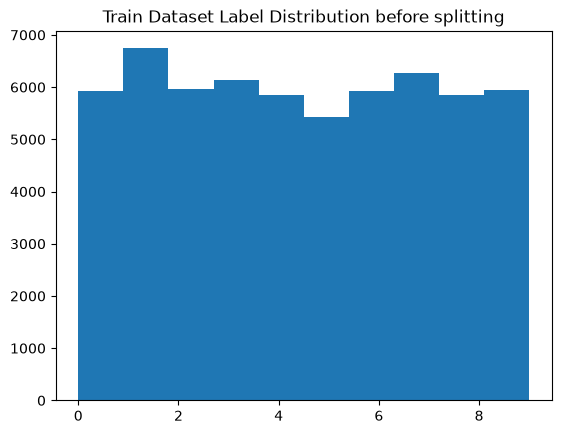

In [7]:
labels = torch.tensor([y for x, y in train_dataset])

plt.hist(labels, bins=10)
plt.title("Train Dataset Label Distribution before splitting")

In [8]:
train_split, val_split = model_selection.train_test_split(train_dataset, test_size=0.2, stratify=labels, random_state=SEED)

### Display proportions after train/val split

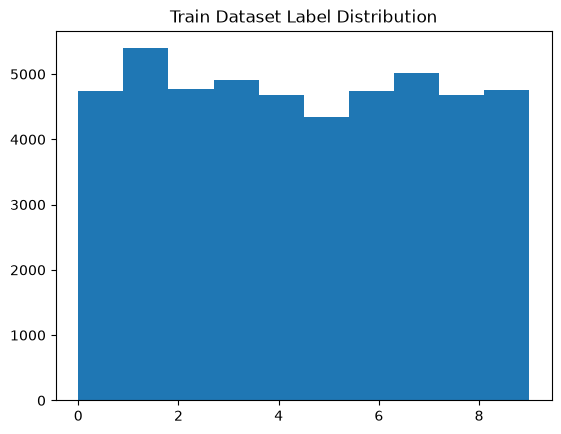

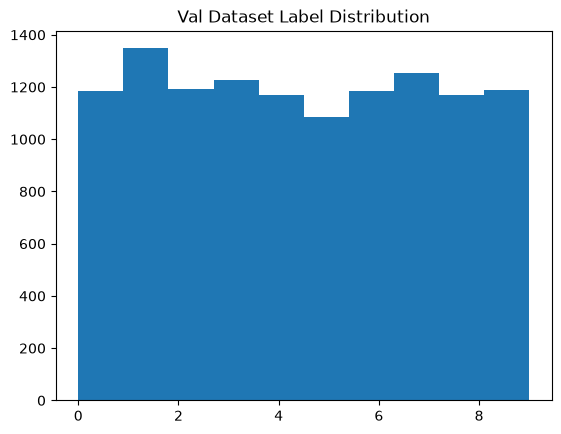

In [9]:
train_labels = torch.tensor([y for x, y in train_split])
val_labels = torch.tensor([y for x, y in val_split])

plt.hist(train_labels, bins=10)
plt.title("Train Dataset Label Distribution")
plt.show()

plt.hist(val_labels, bins=10)
plt.title("Val Dataset Label Distribution")
plt.show()

### Convert to torch dataset

In [10]:
class ColoredMNISTDataset(data.Dataset):
	"""Wrapper class that applies coloring based on the target class ID."""
	def __init__(self, dataset_list, transform=None, colored_proportions=0.95, colors_list=COLORS):
		"""
			Initialize 
		"""
		super().__init__()
		self.colors_list = colors_list
		self.pil_to_tensor = v2.Compose(
			[
				v2.ToImage(),
				v2.ToDtype(torch.float32, scale=True)
			]
		)

		self.x = []
		for x, y in dataset_list:
			if torch.rand(1).item() < colored_proportions:
				colored_image = self._gray_to_colored(self.pil_to_tensor(x), y)
				self.x.append(colored_image)
			else:
				w, h = x.size
				self.x.append(self.pil_to_tensor(x).expand(1, 3, w, h))

		self.x = torch.cat(self.x, dim=0)
		self.y = torch.tensor([y for x, y in dataset_list])
		self.transform = transform

	def __len__(self):
		return len(self.x)
	
	def __getitem__(self, index):
		if self.transform is not None:
			return self.transform(self.x[index]), self.y[index]
		return self.x[index], self.y[index]
	
	def _gray_to_colored(self, x, y):
		assert len(self.colors_list) > y, f"Color index {y} is out of range for COLORS list."

		color = self.colors_list[y]
		colored_image = torch.zeros(3, x.shape[1], x.shape[2])
		colored_image[0] = x * int(color[1:3], 16) / 255.0
		colored_image[1] = x * int(color[3:5], 16) / 255.0
		colored_image[2] = x * int(color[5:7], 16) / 255.0
		return colored_image.unsqueeze(0)

In [11]:
class Model(nn.Module):
	def __init__(self, n_classes=10):
		super().__init__()
		self.fc = nn.Sequential(
			nn.Flatten(),
			nn.Linear(3*784, 2048),
			nn.Tanh(),
			nn.Linear(2048, 512),
			nn.Tanh(),
			nn.Linear(512, 64),
			nn.Tanh(),
			nn.Linear(64, n_classes)
		)

	def forward(self, x):
		return self.fc(x)		

In [12]:
def train_one_epoch(model, train_dl, criterion, optimizer, metrics_calculator, device="cuda"):
	"""
	Performs the optimization over the whole dataset once.
	Resets the metrics_calculator at the beggining and updates metrics inplace but does not return the metrics directly.
	Those can be accesed outside of this function.

	Args:
		model: Model trained.
		train_dl: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used for updating model's weights.
		metrics_calculator: Instance of metrics calculator used for computing metrics on train dataset.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean training loss for current epoch.
	"""

	metrics_calculator.reset()
	model.train()
	train_epoch_loss = 0
	n_instances = 0
	
	for inputs, targets in tqdm.tqdm(train_dl, desc="Training"):
		optimizer.zero_grad()

		inputs = inputs.to(device)
		targets = targets.to(device)

		outputs = model(inputs)

		loss = criterion(outputs, targets)
		loss.backward()
		optimizer.step()

		train_epoch_loss += loss.item()
		metrics_calculator.update(outputs.detach(), targets.detach())
		n_instances += inputs.shape[0]
	
	mean_epoch_loss = train_epoch_loss / n_instances
	return mean_epoch_loss

@torch.no_grad()
def evaluate(model, dataloader, criterion, metrics_calculator, device="cuda"):
	"""
	Evaluates the model given a dataloader

	Args:
		model: Model to evaluate.
		dataloader: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		metrics_calculator: Instance of metrics calculator used for computing metrics.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean loss.
	"""

	metrics_calculator.reset()
	model.eval()
	total_loss = 0
	n_instances = 0
	
	for inputs, targets in tqdm.tqdm(dataloader, desc="Evaluating"):
		inputs = inputs.to(device)
		targets = targets.to(device)

		outputs = model(inputs)

		loss = criterion(outputs, targets)

		total_loss += loss.item()
		metrics_calculator.update(outputs.detach(), targets.detach())
		n_instances += inputs.shape[0]
	
	mean_loss = total_loss / n_instances
	return mean_loss


def train(model, train_dl, val_dl, criterion, optimizer, metrics_calculator, epochs=10, device="cuda"):
	"""
	Trains the model for the specified number of epochs.

	Args:
		model: Model trained.
		train_dl: Dataloader with training data.
		val_dl: Dataloader with validation data.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used to update model parameters.
		metrics_calculator: Instance of metrics calculator used for computing metrics.
		epochs (optional): Number of epochs to train the model for.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		list[float]: List of training loss in each epoch.
		list[float]: List of validation loss in each epoch.
	"""
	best_weights = model.state_dict()
	best_val_loss = float("inf")
	train_losses = []
	val_losses = []

	for epoch in range(epochs):
		train_loss = train_one_epoch(model, train_dl, criterion, optimizer, metrics_calculator, device)
		accuracy, precision, recall, f1_score, auprc, auroc = metrics_calculator.compute_all()
		val_loss = evaluate(model, val_dl, criterion, metrics_calculator, device)
		accuracy, precision, recall, f1_score, auprc, auroc = metrics_calculator.compute_all()

		print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1_score:.4f}, AUPRC: {auprc:.4f}, AUROC: {auroc:.4f}")

		train_losses.append(train_loss)
		val_losses.append(val_loss)

		if val_loss < best_val_loss:
			best_val_loss = val_loss
			best_weights = model.state_dict()

	model.load_state_dict(best_weights)

	return train_losses, val_losses

Proportion of colored images: 0.95


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 284.04it/s]


Epoch 1/10 - Train Loss: 0.0022, Val Loss: 0.0013, Accuracy: 0.9850, Precision: 0.9850, Recall: 0.9850, F1 Score: 0.9850, AUPRC: 0.9977, AUROC: 0.9993


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 283.61it/s]


Epoch 2/10 - Train Loss: 0.0009, Val Loss: 0.0009, Accuracy: 0.9903, Precision: 0.9903, Recall: 0.9903, F1 Score: 0.9903, AUPRC: 0.9985, AUROC: 0.9995


...

Epoch 8/10 - Train Loss: 0.0004, Val Loss: 0.0008, Accuracy: 0.9932, Precision: 0.9932, Recall: 0.9932, F1 Score: 0.9932, AUPRC: 0.9979, AUROC: 0.9993


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 283.91it/s]


Epoch 9/10 - Train Loss: 0.0004, Val Loss: 0.0008, Accuracy: 0.9927, Precision: 0.9927, Recall: 0.9927, F1 Score: 0.9927, AUPRC: 0.9979, AUROC: 0.9993


Evaluating: 100%|██████████| 375/375 [00:01<00:00, 284.24it/s]


Epoch 10/10 - Train Loss: 0.0004, Val Loss: 0.0006, Accuracy: 0.9947, Precision: 0.9947, Recall: 0.9947, F1 Score: 0.9947, AUPRC: 0.9982, AUROC: 0.9994


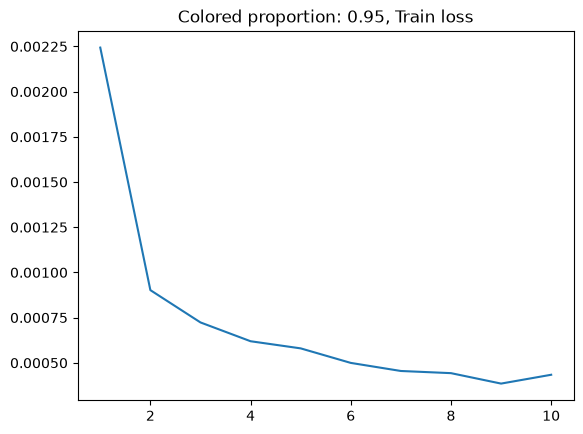

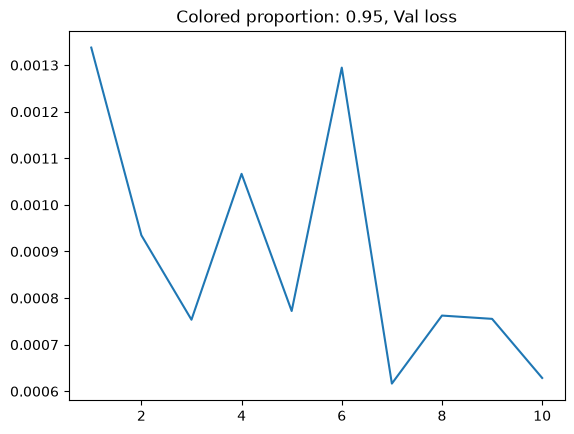

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 285.65it/s]

Performance on clean validation set:
Clean Val Loss: 0.0125, Accuracy: 0.8895, Precision: 0.8895, Recall: 0.8895, F1 Score: 0.8895, AUPRC: 0.9348, AUROC: 0.9851
Performance on fully colored validation set:
Colored Val Loss: 0.0000, Accuracy: 0.9997, Precision: 0.9997, Recall: 0.9997, F1 Score: 0.9997, AUPRC: 1.0000, AUROC: 1.0000


In [14]:
metrics_calculator = metrics.MetricsCalculator(num_classes=len(train_labels.unique()))

model_weights = [] # Best weights for each colored proportion

for proportion in COLORED_PROPORTIONS[-2:-1]:
	print(f"Proportion of colored images: {proportion}")
	metrics_calculator.reset()
	
	train_dataset = ColoredMNISTDataset(train_split, colored_proportions=proportion)
	val_dataset = ColoredMNISTDataset(val_split, colored_proportions=proportion)
	clean_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=0)
	colored_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=1)

	train_dataloader = data.DataLoader(train_dataset, batch_size=TRAIN_BS, shuffle=True)
	val_dataloader = data.DataLoader(val_dataset, batch_size=VAL_BS)
	clean_val_dataloader = data.DataLoader(clean_val_dataset, batch_size=VAL_BS)
	colored_val_dataloader = data.DataLoader(colored_val_dataset, batch_size=VAL_BS)

	model = Model()
	model.to(device)

	optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
	criterion = nn.CrossEntropyLoss()

	# Train the model
	train_losses, val_losses = train(model, train_dataloader, val_dataloader, criterion, optimizer, metrics_calculator, device=device)

	# Save model weights in list to reuse later
	model_weights.append(model.state_dict())
	
	# Plot results
	utils.plot_loss(train_losses, f"Colored proportion: {proportion}, Train loss")
	utils.plot_loss(val_losses, f"Colored proportion: {proportion}, Val loss")

	# Evaluate the model on clean validation dataset
	clean_val_loss = evaluate(model, clean_val_dataloader, criterion, metrics_calculator, device)
	clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

	# Evaluate the model on fully colored validation dataset
	colored_val_loss = evaluate(model, colored_val_dataloader, criterion, metrics_calculator, device)
	colored_val_accuracy, colored_val_precision, colored_val_recall, colored_val_f1_score, colored_val_auprc, colored_val_auroc = metrics_calculator.compute_all()

	print("Performance on clean validation set:")
	print(f"Clean Val Loss: {clean_val_loss:.4f}, Accuracy: {clean_val_accuracy:.4f}, Precision: {clean_val_precision:.4f}, Recall: {clean_val_recall:.4f}, F1 Score: {clean_val_f1_score:.4f}, AUPRC: {clean_val_auprc:.4f}, AUROC: {clean_val_auroc:.4f}")
	print("Performance on fully colored validation set:")
	print(f"Colored Val Loss: {colored_val_loss:.4f}, Accuracy: {colored_val_accuracy:.4f}, Precision: {colored_val_precision:.4f}, Recall: {colored_val_recall:.4f}, F1 Score: {colored_val_f1_score:.4f}, AUPRC: {colored_val_auprc:.4f}, AUROC: {colored_val_auroc:.4f}")


In [17]:
# model.load_state_dict(model_weights[-2])
model.load_state_dict(model_weights[-1])
model.eval()

Model(
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=2048, bias=True)
    (2): Tanh()
    (3): Linear(in_features=2048, out_features=512, bias=True)
    (4): Tanh()
    (5): Linear(in_features=512, out_features=64, bias=True)
    (6): Tanh()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [18]:
# Evaluate the model on clean validation dataset
clean_val_loss = evaluate(model, clean_val_dataloader, criterion, metrics_calculator, device)
clean_val_accuracy, clean_val_precision, clean_val_recall, clean_val_f1_score, clean_val_auprc, clean_val_auroc = metrics_calculator.compute_all()

# Evaluate the model on fully colored validation dataset
colored_val_loss = evaluate(model, colored_val_dataloader, criterion, metrics_calculator, device)
colored_val_accuracy, colored_val_precision, colored_val_recall, colored_val_f1_score, colored_val_auprc, colored_val_auroc = metrics_calculator.compute_all()

print("Performance on clean validation set:")
print(f"Clean Val Loss: {clean_val_loss:.4f}, Accuracy: {clean_val_accuracy:.4f}, Precision: {clean_val_precision:.4f}, Recall: {clean_val_recall:.4f}, F1 Score: {clean_val_f1_score:.4f}, AUPRC: {clean_val_auprc:.4f}, AUROC: {clean_val_auroc:.4f}")
print("Performance on fully colored validation set:")
print(f"Colored Val Loss: {colored_val_loss:.4f}, Accuracy: {colored_val_accuracy:.4f}, Precision: {colored_val_precision:.4f}, Recall: {colored_val_recall:.4f}, F1 Score: {colored_val_f1_score:.4f}, AUPRC: {colored_val_auprc:.4f}, AUROC: {colored_val_auroc:.4f}")

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 234.06it/s]

Performance on clean validation set:
Clean Val Loss: 0.0125, Accuracy: 0.8895, Precision: 0.8895, Recall: 0.8895, F1 Score: 0.8895, AUPRC: 0.9348, AUROC: 0.9851
Performance on fully colored validation set:
Colored Val Loss: 0.0000, Accuracy: 0.9997, Precision: 0.9997, Recall: 0.9997, F1 Score: 0.9997, AUPRC: 1.0000, AUROC: 1.0000


In [19]:
colors_flipped_val_dataset = ColoredMNISTDataset(val_split, colored_proportions=1, colors_list=COLORS[::-1])
colors_flipped_val_dataloader = torch.utils.data.DataLoader(colors_flipped_val_dataset, batch_size=VAL_BS, shuffle=False)

colors_flipped_val_loss = evaluate(model, colors_flipped_val_dataloader, criterion, metrics_calculator, device)
colors_flipped_val_accuracy, colors_flipped_val_precision, colors_flipped_val_recall, colors_flipped_val_f1_score, colors_flipped_val_auprc, colors_flipped_val_auroc = metrics_calculator.compute_all()

print("Performance on validation set with colors flipped:")
print(f"Colors flipped Val Loss: {colors_flipped_val_loss:.4f}, Accuracy: {colors_flipped_val_accuracy:.4f}, Precision: {colors_flipped_val_precision:.4f}, Recall: {colors_flipped_val_recall:.4f}, F1 Score: {colors_flipped_val_f1_score:.4f}, AUPRC: {colors_flipped_val_auprc:.4f}, AUROC: {colors_flipped_val_auroc:.4f}")

Evaluating: 100%|██████████| 375/375 [00:01<00:00, 211.26it/s]

Performance on validation set with colors flipped:
Colors flipped Val Loss: 0.1886, Accuracy: 0.2733, Precision: 0.2733, Recall: 0.2733, F1 Score: 0.2733, AUPRC: 0.3383, AUROC: 0.7079


# Sparse autoencoder

In [139]:
SAE_BS = 1024
SAE_ALPHA = 1 # Used to balance between reconstruction and sparsity loss
SAE_TOPK = 5
SAE_HIDDEN_DIM = 256

In [76]:
class SAE(nn.Module):
	"""Sparse autoencoder built from simple Linear layers."""
	def __init__(self, n_inputs: int, n_hidden: int) -> None:
		"""
		Initialize function.

		Args:
			n_inputs: Shape of input layer.
			n_hidden: Shape of hidden vector.
		"""
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Linear(n_inputs, n_hidden),
			nn.ReLU()
		)
		self.decoder = nn.Linear(n_hidden, n_inputs)
		
	def encode(self, x: torch.Tensor) -> torch.Tensor:
		"""
		Encodes the input using using encoder layer.

		Args:
			x: Input tensor.
		Returns:
			torch.Tensor: Autoencoder hidden vector.
		"""
		return self.encoder(x)

	def decode(self, hidden: torch.Tensor) -> torch.Tensor:
		"""
		Decodes the input using using decoder layer.

		Args:
			hidden: Hidden vector which is an output of the encoder layer.
		Returns:
			torch.Tensor: Reconstructed output.
		"""
		return self.decoder(hidden)		

	def forward(self, x):
		"""
		Forward function that encodes the input and reconstructs it using decoder.

		Args:
			x: Input tensor.

		Returns:
			torch.Tensor: Reconstructed input.
			torch.Tensor: Hidden vector which is an output of the encoder layer.
		"""
		hidden = self.encode(x)
		output = self.decode(hidden)
		return output, hidden

In [101]:
class TopkSAE(nn.Module):
	"""Sparse autoencoder built from simple Linear layers."""
	def __init__(self, n_inputs: int, n_hidden: int, topk: int) -> None:
		"""
		Initialize function.

		Args:
			n_inputs: Shape of input layer.
			n_hidden: Shape of hidden vector.
		"""
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Linear(n_inputs, n_hidden),
			nn.ReLU()
		)
		self.decoder = nn.Linear(n_hidden, n_inputs)
		self.topk = topk
		
	def encode(self, x: torch.Tensor) -> torch.Tensor:
		"""
		Encodes the input using using encoder layer. Doesn't apply topk.

		Args:
			x: Input tensor.
		Returns:
			torch.Tensor: Autoencoder hidden vector.
		"""
		return self.encoder(x)

	def decode(self, hidden: torch.Tensor) -> torch.Tensor:
		"""
		Decodes the input using using decoder layer.

		Args:
			hidden: Hidden vector which is an output of the encoder layer.
		Returns:
			torch.Tensor: Reconstructed output.
		"""
		return self.decoder(hidden)		

	def forward(self, x):
		"""
		Forward function that encodes the input, applies topk and reconstructs it using decoder.

		Args:
			x: Input tensor.

		Returns:
			torch.Tensor: Reconstructed input.
			torch.Tensor: Sparse hidden vector which is an output of the encoder layer.
		"""
		hidden = self.encode(x)

		values, indices = torch.topk(hidden, self.topk, dim=1)
		sparse_hidden = torch.zeros_like(hidden)
		sparse_hidden.scatter_(1, indices, values)

		output = self.decode(sparse_hidden)
		return output, sparse_hidden

In [ ]:
sae_input_shape = model.fc[-1].in_features

In [78]:
@torch.no_grad()
def generate_sae_dataset(model: nn.Module, dataset: data.Dataset) -> data.TensorDataset:
	"""
	Function for generating SAE dataset based on a model and a dataset.
	Uses model's last layer input as a reconstruction target for SAE.

	Args:
		model: Model which embeddings are to be extracted.
		dataset: Dataset with input images to be encoded by the model.

	Returns:
		data.TensorDataset: SAE dataset with encoded images.
	"""
	sae_input_shape = model.fc[-1].in_features
	sae_dataset = torch.empty(len(dataset), sae_input_shape)

	idx = 0
	for inputs, targets in tqdm.tqdm(dataset):
		inputs = inputs.to(device)
		inputs = inputs.unsqueeze(0)
		outputs = model.fc[:-1](inputs).squeeze()
		sae_dataset[idx] = outputs
		idx += 1

	return data.TensorDataset(sae_dataset)

In [79]:
sae_train_dataset = generate_sae_dataset(model, train_dataset)
sae_val_dataset = generate_sae_dataset(model, val_dataset)

sae_train_dataloader = data.DataLoader(sae_train_dataset, SAE_BS, shuffle=True)
sae_val_dataloader = data.DataLoader(sae_val_dataset, SAE_BS, shuffle=False)

100%|██████████| 12000/12000 [00:23<00:00, 521.39it/s]


In [107]:
def sae_train_one_epoch(model, train_dl, criterion, optimizer, device="cuda"):
	"""
	Performs the SAE optimization over the whole dataset once.

	Args:
		model: Model trained.
		train_dl: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		optimizer: Optimizer used for updating model's weights.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean training loss for current epoch.
		float: Mean number of active hidden vector neurons in each batch.
	"""

	model.train()
	train_epoch_loss = 0
	total_active_neurons = 0
	n_instances = 0

	is_topk = isinstance(criterion, nn.MSELoss)
	
	for sae_inputs in tqdm.tqdm(train_dl, desc="Training"):
		optimizer.zero_grad()

		# data.TensorDataset returns list of len 1 so this retrieves all batches as torch.Tensor
		sae_inputs = sae_inputs[0].to(device)

		outputs, hidden = model(sae_inputs)

		if is_topk:
			loss = criterion(outputs, sae_inputs)
		else:
			loss = criterion(outputs, sae_inputs, hidden)

		active_neurons = torch.sum(hidden > 0)

		loss.backward()
		optimizer.step()

		train_epoch_loss += loss.item()
		total_active_neurons += active_neurons.item()
		n_instances += sae_inputs.shape[0]
	
	mean_epoch_loss = train_epoch_loss / n_instances
	mean_active_neurons = total_active_neurons / n_instances
	return mean_epoch_loss, mean_active_neurons

@torch.no_grad()
def sae_evaluate(model, dataloader, criterion, device="cuda"):
	"""
	Evaluates SAE given a dataloader

	Args:
		model: Model to evaluate.
		dataloader: Dataloader with data used for training.
		criterion: Criterion used for calculating the loss.
		device (optional): Device used for calculations like CUDA or CPU.
	Returns:
		float: Mean loss.
		float: Mean number of active hidden vector neurons in each batch.
	"""

	model.eval()
	total_loss = 0
	total_active_neurons = 0
	n_instances = 0

	is_topk = isinstance(criterion, nn.MSELoss)
	
	for sae_inputs in tqdm.tqdm(dataloader, desc="Evaluating"):
		# data.TensorDataset returns list of len 1 so this retrieves all batches as torch.Tensor
		sae_inputs = sae_inputs[0].to(device)

		outputs, hidden = model(sae_inputs)

		if is_topk:
			loss = criterion(outputs, sae_inputs)
		else:
			loss = criterion(outputs, sae_inputs, hidden)

		active_neurons = torch.sum(hidden > 0)

		total_loss += loss.item()
		total_active_neurons += active_neurons.item()
		n_instances += sae_inputs.shape[0]
	
	mean_loss = total_loss / n_instances
	mean_active_neurons = total_active_neurons / n_instances
	return mean_loss, mean_active_neurons

def sae_train(model, train_dl, val_dl, criterion, optimizer, epochs=10, device="cuda"):
	"""
	Function to train SAE model using dataset with embeddings from image classification model.

	Args:
		model: SAE model to train.
		train_dl: Dataset with training embeddings.
		val_dl: Dataset with validation embeddings.
		criterion: Criterion used to calculate SAE loss.
		optimizer: Optimizer used to update SAE params.
		epochs (optional): Number of epochs to train SAE for.
		device (optional): Device used for calculations like CUDA or CPU.
	"""

	best_weights = model.state_dict()
	best_val_loss = float("inf")
	train_losses = []
	val_losses = []

	for epoch in range(epochs):
		train_loss, train_mean_active_neurons = sae_train_one_epoch(model, train_dl, criterion, optimizer, device)
		val_loss, val_mean_active_neurons = sae_evaluate(model, val_dl, criterion, device)

		print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train active neurons: {train_mean_active_neurons:.4f}, Val active neurons: {val_mean_active_neurons:.4f}")

		train_losses.append(train_loss)
		val_losses.append(val_loss)

		if val_loss < best_val_loss:
			best_val_loss = val_loss
			best_weights = model.state_dict()

	model.load_state_dict(best_weights)

	return train_losses, val_losses

In [ ]:
def sae_criterion_fn(outputs, targets, hidden, alpha=0.5):
    """
    SAE criterion that applies both L1 loss on hidden SAE vector as well as L2 reconstruction loss.
    
    Args:
		outputs: Output of the SAE decoder.
        targets: Target used for reconstruction loss.
        hidden: Sparse hidden vector, output of the SAE's encoder.
        alpha (optional): Weight applied to sparsity loss.
    Returns:
		torch.Tensor: Combined sparsity and reconstruction loss.
    """
    mae = torch.mean(torch.abs(hidden))	# L1 Loss to ensure hidden layer sparsity
    reconstruction_loss = torch.mean((outputs-targets)**2)
    return reconstruction_loss+alpha*mae

In [140]:
sae_model = TopkSAE(sae_input_shape, SAE_HIDDEN_DIM, topk=SAE_TOPK)
sae_model.to(device)
sae_optimizer = torch.optim.Adam(sae_model.parameters(), lr=1e-3)
# sae_criterion = functools.partial(sae_criterion_fn, alpha=SAE_ALPHA)
sae_criterion = nn.MSELoss()

In [141]:
sae_train(sae_model, sae_train_dataloader, sae_val_dataloader, sae_criterion, sae_optimizer, epochs=30, device=device)

Evaluating: 100%|██████████| 12/12 [00:00<00:00, 73.31it/s]


Epoch 1/30 - Train Loss: 0.0005, Val Loss: 0.0001, Train active neurons: 5.0000, Val active neurons: 5.0000


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 77.21it/s]


Epoch 2/30 - Train Loss: 0.0001, Val Loss: 0.0001, Train active neurons: 5.0000, Val active neurons: 5.0000


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 79.03it/s]


...

Evaluating: 100%|██████████| 12/12 [00:00<00:00, 76.65it/s]


Epoch 29/30 - Train Loss: 0.0000, Val Loss: 0.0000, Train active neurons: 5.0000, Val active neurons: 5.0000


Evaluating: 100%|██████████| 12/12 [00:00<00:00, 74.45it/s]

Epoch 30/30 - Train Loss: 0.0000, Val Loss: 0.0000, Train active neurons: 5.0000, Val active neurons: 5.0000


([0.0005098302718251944,
  8.55244363968571e-05,
  6.291664081315199e-05,
  5.673746104973058e-05,
  5.3187566964576644e-05,
  5.062515715447565e-05,
  4.8536209156736734e-05,
  4.68863684994479e-05,
  4.56378854966412e-05,
  4.4516513434549175e-05,
  4.339759222542246e-05,
  4.223055757271747e-05,
  4.1142298296714823e-05,
  4.0198731080939375e-05,
  3.92723746287326e-05,
  3.834082488901913e-05,
  3.749160973044733e-05,
  3.665314405225217e-05,
  3.594019877103468e-05,
  3.536214656196535e-05,
  3.485939581878483e-05,
  3.432138683274388e-05,
  3.3689057376856605e-05,
  3.310238244011998e-05,
  3.256770289347818e-05,
  3.2130770036019384e-05,
  3.162370059483995e-05,
  3.1228939536958934e-05,
  3.0862188665196296e-05,
  3.0396136920899154e-05],
 [0.0001304028034210205,
  6.88529002169768e-05,
  6.004787950466077e-05,
  5.5682924576103686e-05,
  5.2557775440315405e-05,
  5.0352369124690695e-05,
  4.848122037947178e-05,
  4.696982943763335e-05,
  4.577846390505632e-05,
  4.467611387372

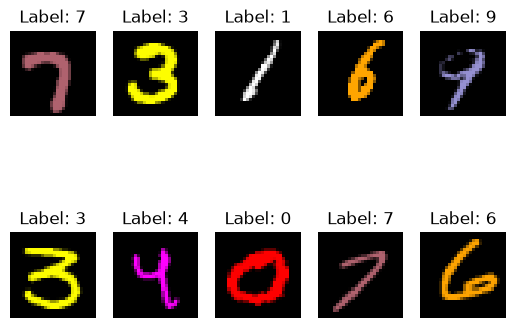

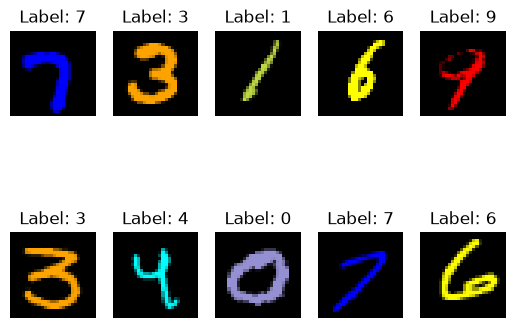

In [142]:
utils.show_from_dataset(val_dataset, range(0, 10))
utils.show_from_dataset(colors_flipped_val_dataset, range(0, 10))

In [143]:
for i in range(10):
	input, target = val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:-1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, sae_model.topk)
	print(f"Colors not flipped {i}: {indices}")

	input, target = colors_flipped_val_dataset[i]
	input = input.to(device)
	input = input.unsqueeze(0)
	embedding = model.fc[:-1](input)

	output, hidden = sae_model(embedding)
	values, indices = torch.topk(hidden, sae_model.topk)
	print(f"Colors flipped {i}: {indices}")

Colors not flipped 0: tensor([[139,  86,  37, 252,  18]], device='mps:0')
Colors flipped 0: tensor([[ 67, 207, 106, 159,  72]], device='mps:0')
Colors not flipped 1: tensor([[226,  63, 118,  30,  82]], device='mps:0')
Colors flipped 1: tensor([[226,  63,  30,  34, 139]], device='mps:0')
Colors not flipped 2: tensor([[138, 223, 213,   2,  97]], device='mps:0')
Colors flipped 2: tensor([[ 99, 190, 213, 138, 223]], device='mps:0')
Colors not flipped 3: tensor([[ 34,  96, 133, 166, 245]], device='mps:0')
Colors flipped 3: tensor([[ 34, 133, 203, 226, 108]], device='mps:0')
Colors not flipped 4: tensor([[150, 250, 194,  59,  65]], device='mps:0')
Colors flipped 4: tensor([[139, 238,  48, 177,  34]], device='mps:0')
Colors not flipped 5: tensor([[ 63,  30, 226,  82, 183]], device='mps:0')
Colors flipped 5: tensor([[ 63, 226,  30, 183,  82]], device='mps:0')
Colors not flipped 6: tensor([[ 53,  12,  22, 111, 133]], device='mps:0')
Colors flipped 6: tensor([[ 57,  97, 151, 189, 185]], device='